<a href="https://colab.research.google.com/github/Y262521/-Email-Spam-Detection/blob/main/Email_Spam_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install streamlit pyngrok joblib -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 48.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 74.4 MB/s eta 0:00:00


In [2]:
import pandas as pd
import re
import joblib
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score


url = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"
df = pd.read_table(url, header=None, names=['label', 'message'])

In [3]:
df['label_num'] = df.label.map({'ham': 0, 'spam': 1})
df.drop_duplicates(inplace=True)


In [4]:
print("First 5 Rows")
print(df.head())

print("\nDataset Information")
print(df.info())

print("\nMissing Values")
print(df.isnull().sum())

print("\nSpam vs Ham Count")
print(df['label'].value_counts())

First 5 Rows
  label                                            message  label_num
0   ham  Go until jurong point, crazy.. Available only ...          0
1   ham                      Ok lar... Joking wif u oni...          0
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...          1
3   ham  U dun say so early hor... U c already then say...          0
4   ham  Nah I don't think he goes to usf, he lives aro...          0

Dataset Information
<class 'pandas.core.frame.DataFrame'>
Index: 5169 entries, 0 to 5571
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   label      5169 non-null   object
 1   message    5169 non-null   object
 2   label_num  5169 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 161.5+ KB
None

Missing Values
label        0
message      0
label_num    0
dtype: int64

Spam vs Ham Count
label
ham     4516
spam     653
Name: count, dtype: int64


NameError: name 'plt' is not defined

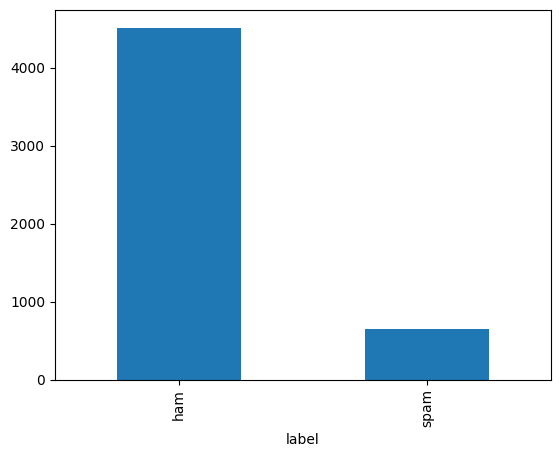

In [5]:
df['label'].value_counts().plot(kind='bar')
plt.title("Spam vs Ham Messages")
plt.xlabel("Message Type")
plt.ylabel("Count")
plt.show()

In [6]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    return text

df['clean_message'] = df['message'].apply(clean_text)



In [7]:
tfidf = TfidfVectorizer(stop_words='english')
X = tfidf.fit_transform(df['clean_message'])
y = df['label_num']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


In [9]:
model = MultinomialNB()
model.fit(X_train, y_train)

MultinomialNB()

In [13]:
y_pred = model.predict(X_test)
print(f" Model Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")

 Model Accuracy: 96.52%


In [14]:
joblib.dump(model, "spam_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

print("\nModel and Vectorizer saved successfully!")


Model and Vectorizer saved successfully!


In [15]:
%%writefile app.py
import streamlit as st
import joblib


model = joblib.load('spam_model.pkl')
tfidf = joblib.load('tfidf_vectorizer.pkl')

st.title("📩 Spam Email / SMS Detector")
st.write("Enter any message below to predict whether it is Spam or Ham.")

user_input = st.text_area("Message Input:")

if st.button("Predict"):
    if user_input.strip() != "":
        vectorized = tfidf.transform([user_input])
        prediction = model.predict(vectorized)

        if prediction[0] == 1:
            st.error("🚫 This message is SPAM!")
        else:
            st.success("✅ This message is HAM (Legitimate).")
    else:
        st.warning("Please enter some text first.")

Writing app.py


In [ ]:
!wget -q -O cloudflared https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64

!chmod +x cloudflared

import subprocess

subprocess.Popen(["streamlit", "run", "app.py"])

!./cloudflared tunnel --url http://localhost:8501

2026-08-04T20:23:07Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-08-04T20:23:07Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-08-04T20:23:12Z INF +--------------------------------------------------------------------------------------------+
2026-08-04T20:23:12Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-08-04T20:23:12Z INF |  https://inline-chat-cologne-interstate.trycloudflare.